In [1]:
# ==========================================
# 1. INSTALL & IMPORT LIBRARIES
# ==========================================
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
from torchvision.models import resnet50, ResNet50_Weights

In [3]:
# Captum install and import for Explainable AI
try:
    from captum.attr import LayerGradCam
    from captum.attr import visualization as viz
except ImportError:
    print("Installing Captum...")
    os.system('pip install -q captum')
    from captum.attr import LayerGradCam
    from captum.attr import visualization as viz

In [11]:
# ==========================================
# 2. DEFINE IMAGE PREPROCESSING
# ==========================================
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image = Image.open(image_path).convert('RGB')
    return transform(image).unsqueeze(0), image

In [12]:
# ==========================================
# 3. LOAD PRE-TRAINED MODEL
# ==========================================
print("Loading ResNet50 model...")
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)
model.eval()

Loading ResNet50 model...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 148MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [13]:
# 4. DATASET PATH SETUP (Kaggle Specific)
# ==========================================
base_path = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
image_files = glob.glob(os.path.join(base_path, '**/*.jpg'), recursive=True)

if len(image_files) > 0:
    img_path = image_files[0]
    print(f"Success! Found image at: {img_path}")
    
    input_tensor, original_image = preprocess_image(img_path)

Success! Found image at: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg


Predicted Class Index: 78
Captum visualization failed, using basic Matplotlib: axis 2 is out of bounds for array of dimension 2


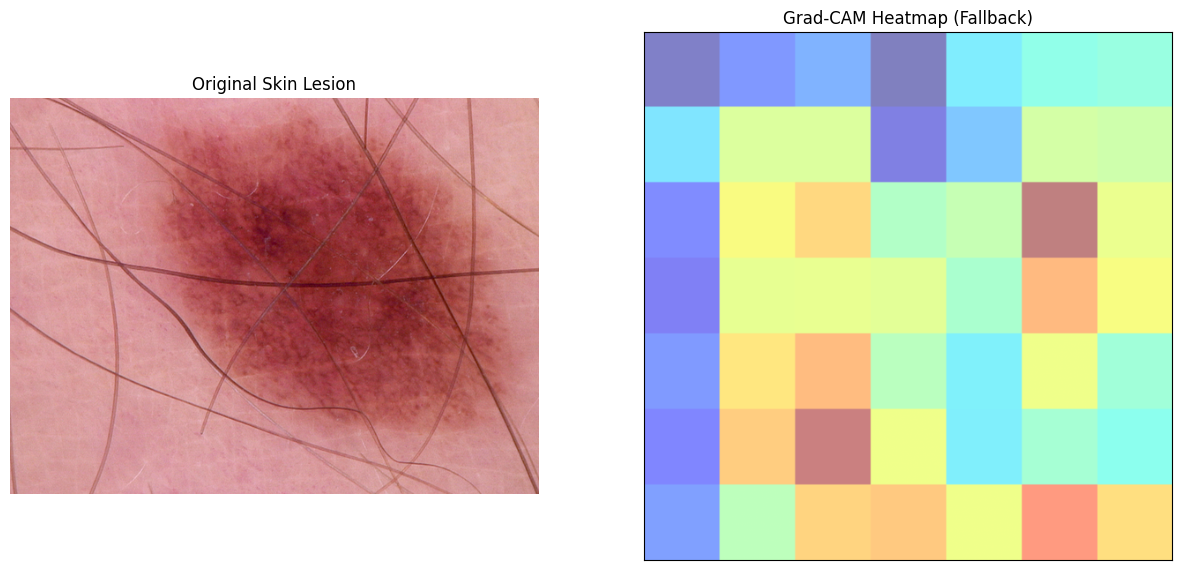

In [16]:
# 1. Prepare data format (Ensure it is in H, W, C format)
attr_np = upsampled_attr.squeeze().cpu().detach().numpy()
img_np = input_tensor.squeeze().cpu().detach().numpy()

# Check dimensions before transposing to avoid ValueError
if len(attr_np.shape) == 3:
    # Converting from (C, H, W) to (H, W, C) for plotting
    vis_attr = np.transpose(attr_np, (1, 2, 0))
    vis_img = np.transpose(img_np, (1, 2, 0))
else:
    # Use as is for Grayscale or different formats
    vis_attr = attr_np
    vis_img = img_np

# 2. Visualize results
print(f"Predicted Class Index: {pred_label_idx.item()}")

fig, ax = plt.subplots(1, 2, figsize=(15, 7))

# Display original image
ax[0].imshow(original_image)
ax[0].set_title("Original Skin Lesion", fontsize=12)
ax[0].axis('off')

# Display Grad-CAM Heatmap using Captum's visualization tool
try:
    _ = viz.visualize_image_attr(
        vis_attr, 
        vis_img, 
        method="heatmap", 
        sign="all", 
        show_colorbar=True, 
        title="Grad-CAM Focus Area",
        plt_fig_axis=(fig, ax[1])
    )
except Exception as e:
    # Fallback to basic Matplotlib if Captum visualization fails
    print(f"Captum visualization failed, using basic Matplotlib: {e}")
    ax[1].imshow(vis_attr, cmap='jet', alpha=0.5)
    ax[1].set_title("Grad-CAM Heatmap (Fallback)")

plt.show()